# 06-workflow.ipynb

In [5]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()


llm = init_chat_model('gpt-4.1-mini')

## Prompt Chaining

- 매우 잘 정리된 업무 순서가 있을 경우 사용
- 이전 노드에서 처리한 내용을 `state`에 담아 다음 노드로 전송

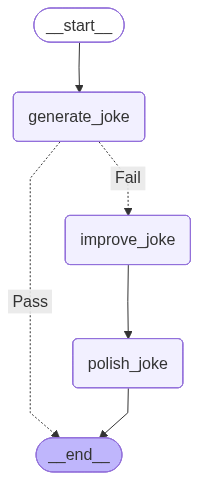

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
# 그림 보는 용
from IPython.display import Image, display


# Graph State
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'주제 {state['topic']}에 관련된 짧은 농담 생성')
    return {'joke': msg.content}

def improve_joke(state: State):
    msg = llm.invoke(f'말장난을 추가해서 아래 농담을 더 재밌게 만들어보자.\n {state['joke']}')
    return {'improved_joke':msg.content}

def polish_joke(state: State):
    msg = llm.invoke(f'아래 농담을 쩔게 뒤틀어 보자. \n {state['improved_joke']}')
    return {'final_joke':msg.content}

# Router
def check_punchline(state: State):
    # ? 나 ! 없으면, 농담을 improve 하고, 있으면 그대로 진행
    if '?' in state['joke'] or '!' in state['joke']:
        return 'Pass'
    else:
        return 'Fail'
    

workflow = StateGraph(State)

# Add node
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {
        'Pass': END,
        'Fail': 'improve_joke'
    })
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)
graph = workflow.compile()
graph


In [7]:
graph.invoke({'topic': '랭체인'})

{'topic': '랭체인', 'joke': '랭체인 쓰다가 길 잃었대요.  \n"이게 체인 맞아? 길이 없잖아!"'}

## Parallelization (병렬화)
- 여러 node(llm)이 동시에 작업을 진행
- 뭐가 먼저 끝날지 알 수 없음
- 하위 태스크를 동시에 진행시켜서 속도 up
- 같은 태스크를 여러번 동시에 돌려서 신뢰성 확보

In [8]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    output: str

In [16]:
# Nodes
def  generate_joke(state: State):
    msg = llm.invoke(f'Write a joke about {state['topic']}')
    return {'joke': msg.content}

def  generate_story(state: State):
    msg = llm.invoke(f'Write a story about {state['topic']}')
    return {'story': msg.content}

def  generate_poem(state: State):
    msg = llm.invoke(f'Write a poem about {state['topic']}')
    return {'poem': msg.content}

def  aggregate(state: State):
    output = f"""농담, 이야기, 시
Joke: {state['joke']}
Story: {state['story']}
Poem: {state['poem']}
"""
    return {'output': output}



workflow = StateGraph(State)

# Add node
workflow.add_node(generate_joke)
workflow.add_node(generate_story)
workflow.add_node(generate_poem)
workflow.add_node(aggregate)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_edge(START, "generate_story")
workflow.add_edge(START, "generate_poem")
workflow.add_edge("generate_joke", "aggregate")
workflow.add_edge("generate_story", "aggregate")
workflow.add_edge("generate_poem", "aggregate")
workflow.add_edge("aggregate", END)

graph = workflow.compile()
graph.invoke({'topic': '바보'})

{'topic': '바보',
 'joke': '왜 바보가 컴퓨터 앞에서 춤을 출까요?  \n왜냐하면 ‘바보’니까, ‘버그’를 잡으려다 춤판이 벌어졌대요!',
 'story': '옛날 옛적에, 작은 마을에 ‘바보’라는 별명을 가진 한 소년이 살고 있었습니다. 사람들은 그를 바보라고 불렀지만, 그는 자신이 바보라고 생각하지 않았습니다. 오히려 그는 세상을 있는 그대로 바라보는 순수한 마음을 가진 아이였습니다.\n\n바보는 매일 들판을 뛰어다니며 꽃을 보고, 나비를 따라다녔습니다. 사람들은 그런 그의 모습에 웃음을 지었지만, 바보는 신경 쓰지 않았습니다. 그는 자신만의 방식으로 세상을 사랑했고, 그것이 무엇보다 소중하다고 믿었습니다.\n\n어느 날 큰 비가 내렸고, 마을 근처 강이 범람하기 시작했습니다. 사람들은 두려움에 떨었고, 어떻게든 대책을 세워야 했습니다. 그때 바보는 강가에 모여 있는 사람들 곁에 다가가 조용히 말했습니다.\n\n“우리 모두 합심해서 둑을 쌓는 게 어때요? 작은 흙이나 돌이라도 하나하나 모으면 강물이 막히지 않을 거예요.”\n\n사람들은 처음에는 그의 말을 무시했지만, 바보의 순수한 눈빛과 간절한 마음에 결국 마음을 열고 함께 일하기 시작했습니다. 모두가 힘을 모아 둑을 쌓았고, 결국 큰 홍수로부터 마을을 지킬 수 있었습니다.\n\n그때부터 사람들은 ‘바보’라는 별명이 얼마나 잘못된 것인지 깨닫게 되었습니다. 바보는 단지 다르게 생각하는 소년이었고, 그의 순수함과 용기가 마을 사람들을 구한 영웅이었던 것입니다.\n\n이후로 마을 사람들은 바보를 진심으로 존경하며, 그가 가르쳐 준 소중한 가치를 잊지 않았습니다. 그리고 바보는 언제나처럼 자연과 친구가 되어 행복하게 살았답니다.\n\n끝.',
 'poem': '바보여도 좋아  \n깨진 마음 안아주고  \n서툰 손길 속에  \n진심이 피어나네  \n\n말 못 전한 눈빛도  \n실수로 쌓인 하루도  \n그리움으로 빛나며  \n바보라 부를게, 너  \n\n천천히 걸어가는 길  \n넘어져도 다시 일어

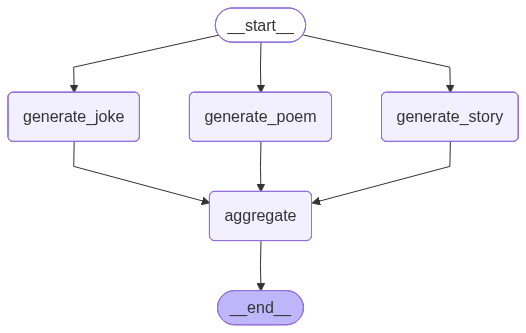

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))

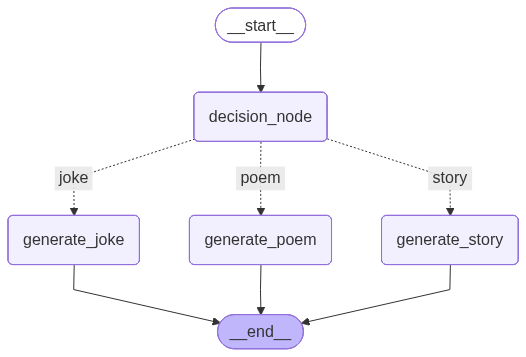

In [28]:
from typing import Literal
from langchain.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

class State(TypedDict):
    input: str
    decision: str
    output: str

# Router에서 사용할 LLM이 쓸 structured output
# {'step': 'poem' | 'story' | 'joke'}
class Route(BaseModel):
    # step 이란 필드는 3개 중 하나지만, 필수(...)고 설명은 ~~~하다
    step: Literal['poem', 'story', 'joke'] = Field(..., description='next step in routing process')

router_llm = llm.with_structured_output(Route)

# State['decision] 을 결정하는 Node
def decision_node(state: State):
    result = rout_llm.invoke(
        [
            SystemMessage(content='사용자 요청에 따라 story, joke, poem을 선택'),
            HumanMessage(content=state['input'])
        ]
    )
    return {'decision': result.step}

def  generate_joke(state: State):
    msg = llm.invoke([
        SystemMessage(content='아주 기발하되 고급스러운 유머를 만들어야 함'),
        HumanMessage(content=state['input'])
    ])
    return {'output': msg.content}

def  generate_story(state: State):
    msg = llm.invoke(state['input'])
    return {'output': msg.content}

def  generate_poem(state: State):
    msg = llm.invoke(state['input'])
    return {'output': msg.content}


# Router
def route_decision(state: State):
    return state['decision']

workflow = StateGraph(State)
workflow.add_node(decision_node)
workflow.add_node(generate_joke)
workflow.add_node(generate_story)
workflow.add_node(generate_poem)

workflow.add_edge(START, 'decision_node')
workflow.add_conditional_edges(
    'decision_node',
    route_decision,
    {
        'joke': 'generate_joke',
        'story': 'generate_story',
        'poem': 'generate_poem'
    }
)
workflow.add_edge('generate_joke', END)
workflow.add_edge('generate_story', END)
workflow.add_edge('generate_poem', END)
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))